In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))
from parse_recipe_ingredient import parse_ingredient_fields

In [2]:
RECIPE_NLG_PATH = "../Data/recipes/RecipeNLG.csv"

# First 10,000 recipe rows only (2.3GB file; avoid loading full CSV).
recipes = pd.read_csv(RECIPE_NLG_PATH, nrows=10_000)
recipes = recipes.rename(columns={"Unnamed: 0": "recipe_id"})

print(f"rows: {len(recipes):,}  columns: {list(recipes.columns)}")
recipes.head()


rows: 10,000  columns: ['recipe_id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']


,recipe_id,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [3]:
recipes['ingredients'].iloc[0]

'["1 c. firmly packed brown sugar", "1/2 c. evaporated milk", "1/2 tsp. vanilla", "1/2 c. broken nuts (pecans)", "2 Tbsp. butter or margarine", "3 1/2 c. bite size shredded rice biscuits"]'

In [4]:
def parse_ingredient_list(value) -> list[str]:
    """Turn a RecipeNLG `ingredients` cell into a list of ingredient strings.

    Most rows store a pseudo-JSON array; splitting on '", "' and trimming
    brackets/quotes recovers the list without parsing the full file as JSON.
    """
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []

    text = str(value).strip()
    if not text or text == "[]":
        return []

    if text.startswith("["):
        text = text[1:]
    if text.endswith("]"):
        text = text[:-1]
    text = text.strip()
    if not text:
        return []

    if '", "' not in text:
        item = text.strip('"')
        return [item] if item else []

    parts = text.split('", "')
    ingredients: list[str] = []
    for i, part in enumerate(parts):
        part = part.strip()
        if i == 0:
            part = part.removeprefix('["').removeprefix('"')
        if i == len(parts) - 1:
            part = part.removesuffix('"]').removesuffix('"')
        if part:
            ingredients.append(part)
    return ingredients


recipes["ingredients_list"] = recipes["ingredients"].map(parse_ingredient_list)

print(f"example: {recipes['ingredients_list'].iloc[0]}")
recipes[["ingredients", "ingredients_list"]].head()

example: ['1 c. firmly packed brown sugar', '1/2 c. evaporated milk', '1/2 tsp. vanilla', '1/2 c. broken nuts (pecans)', '2 Tbsp. butter or margarine', '3 1/2 c. bite size shredded rice biscuits']


,ingredients,ingredients_list
0,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[1 c. firmly packed brown sugar, 1/2 c. evapor..."
1,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[1 small jar chipped beef, cut up, 4 boned chi..."
2,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c..."
3,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[1 large whole chicken, 2 (10 1/2 oz.) cans ch..."
4,"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[1 c. peanut butter, 3/4 c. graham cracker cru..."


In [5]:
recipe_ingredients = (
    recipes[["recipe_id", "ingredients_list"]]
    .explode("ingredients_list")
    .rename(columns={"ingredients_list": "ingredient"})
    .reset_index(drop=True)
)

print(f"recipes: {recipes['recipe_id'].nunique():,}  ingredient rows: {len(recipe_ingredients):,}")
recipe_ingredients.head(10)

recipes: 10,000  ingredient rows: 74,991


,recipe_id,ingredient
0,0,1 c. firmly packed brown sugar
1,0,1/2 c. evaporated milk
2,0,1/2 tsp. vanilla
3,0,1/2 c. broken nuts (pecans)
4,0,2 Tbsp. butter or margarine
5,0,3 1/2 c. bite size shredded rice biscuits
6,1,"1 small jar chipped beef, cut up"
7,1,4 boned chicken breasts
8,1,1 can cream of mushroom soup
9,1,1 carton sour cream


## Ingredient parsing (Approach A)

Uses [`ingredient-parser-nlp`](https://pypi.org/project/ingredient-parser-nlp/) through [`scripts/parse_recipe_ingredient.py`](../scripts/parse_recipe_ingredient.py). Outputs `quantity`, `unit`, `name`, `preparation`, and `parse_status` per ingredient row.

In [6]:
# Approach A: ingredient-parser-nlp via scripts/parse_recipe_ingredient.py (~60–70s for 75k rows)
parsed = recipe_ingredients["ingredient"].map(parse_ingredient_fields)
parsed_df = pd.DataFrame(parsed.tolist())

recipe_ingredients = pd.concat([recipe_ingredients, parsed_df], axis=1)
recipe_ingredients["ingredient_idx"] = recipe_ingredients.groupby("recipe_id").cumcount()

total = len(recipe_ingredients)
print("Parse status:")
print(recipe_ingredients["parse_status"].value_counts())
print(f"\nWith quantity: {recipe_ingredients['quantity'].notna().sum():,} ({100*recipe_ingredients['quantity'].notna().mean():.1f}%)")
print(f"With unit:     {recipe_ingredients['unit'].notna().sum():,} ({100*recipe_ingredients['unit'].notna().mean():.1f}%)")
print(f"With name:     {recipe_ingredients['name'].notna().sum():,} ({100*recipe_ingredients['name'].notna().mean():.1f}%)")

recipe_ingredients[
    [
        "ingredient",
        "quantity",
        "unit",
        "unit_raw",
        "name",
        "size",
        "preparation",
        "parse_status",
        "parse_method",
    ]
].head(12)

Parse status:
parse_status
ok           71049
no_amount     3916
ambiguous       26
Name: count, dtype: int64

With quantity: 70,988 (94.7%)
With unit:     60,869 (81.2%)
With name:     74,991 (100.0%)


,ingredient,quantity,unit,unit_raw,name,size,preparation,parse_status,parse_method
0,1 c. firmly packed brown sugar,1.0,c,1 c,brown sugar,NaN,NaN,ok,ingredient_parser
1,1/2 c. evaporated milk,0.5,c,1/2 c,evaporated milk,NaN,NaN,ok,ingredient_parser
2,1/2 tsp. vanilla,0.5,tsps,1/2 tsps,vanilla,NaN,NaN,ok,ingredient_parser
3,1/2 c. broken nuts (pecans),0.5,c,1/2 c,broken nuts (pecans),NaN,NaN,ok,ingredient_parser
4,2 Tbsp. butter or margarine,2.0,Tbsps,2 Tbsps,"butter, margarine",NaN,NaN,ok,ingredient_parser
5,3 1/2 c. bite size shredded rice biscuits,3.5,c,3 1/2 c,rice biscuits,NaN,bite size shredded,ok,ingredient_parser
6,"1 small jar chipped beef, cut up",1.0,jar,1 jar,beef,NaN,"chipped, cut up",ok,ingredient_parser
7,4 boned chicken breasts,4.0,NaN,4,chicken breasts,NaN,boned,ok,ingredient_parser
8,1 can cream of mushroom soup,1.0,can,1 can,cream of mushroom soup,NaN,NaN,ok,ingredient_parser
9,1 carton sour cream,1.0,carton,1 carton,sour cream,NaN,NaN,ok,ingredient_parser


In [7]:
print("Top units:")
print(recipe_ingredients["unit"].value_counts().head(15).to_string())

print("\nSample comparisons (parsed name vs raw):")
recipe_ingredients.sample(12, random_state=0)[
    ["ingredient", "quantity", "unit", "name", "preparation", "parse_status"]
]

Top units:
unit
c         25007
tsps       7084
tsp        4689
can        4490
Tbsps      3908
oz         2767
Tbsp       2128
lbs        1443
lb         1368
cans        777
box         652
stick       593
dash        437
sticks      431
jar         420

Sample comparisons (parsed name vs raw):


,ingredient,quantity,unit,name,preparation,parse_status
41909,"4 to 6 hard-boiled eggs, chopped",4.00,NaN,eggs,"hard-boiled, chopped",ok
4826,1/2 tsp. salt,0.50,tsps,salt,NaN,ok
23978,1 c. finely minced onion,1.00,c,onion,finely minced,ok
36218,4 Tbsp. nuts,4.00,Tbsps,nuts,NaN,ok
24310,"1 medium onion, chopped",1.00,NaN,onion,chopped,ok
26868,pepperoni,NaN,NaN,pepperoni,NaN,no_amount
62310,cold baked potatoes,NaN,NaN,cold baked potatoes,NaN,no_amount
48172,1 pkg. Hidden Valley Ranch dressing,1.00,NaN,pkg. Hidden Valley Ranch dressing,NaN,ok
30881,2 Tbsp. lemon juice,2.00,Tbsps,lemon juice,NaN,ok
69900,3/4 c. vinegar,0.75,c,vinegar,NaN,ok


In [8]:
import ast

def parse_ner_list(value) -> list[str]:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else []
    except (SyntaxError, ValueError):
        return []


def _as_text(value) -> str | None:
    """Coerce a cell value to str; treat None/NaN/empty as missing."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    text = str(value).strip()
    if not text or text.casefold() == "nan":
        return None
    return text


def ner_matches_parsed(name, ner) -> bool | None:
    n = _as_text(name)
    e = _as_text(ner)
    if n is None or e is None:
        return None
    return n == e or e in n or n in e


recipes["ner_list"] = recipes["NER"].map(parse_ner_list)
recipes["n_ingredients"] = recipes["ingredients_list"].str.len()
recipes["n_ner"] = recipes["ner_list"].str.len()
aligned_recipe_ids = set(
    recipes.loc[recipes["n_ingredients"] == recipes["n_ner"], "recipe_id"]
)

ner_by_recipe = recipes.set_index("recipe_id")["ner_list"].to_dict()
recipe_ingredients["ner_label"] = [
    ner_by_recipe.get(rid, [None] * (idx + 1))[idx]
    if rid in aligned_recipe_ids
    else None
    for rid, idx in zip(
        recipe_ingredients["recipe_id"],
        recipe_ingredients["ingredient_idx"],
        strict=True,
    )
]
recipe_ingredients["ner_match"] = [
    ner_matches_parsed(name, ner)
    for name, ner in zip(recipe_ingredients["name"], recipe_ingredients["ner_label"], strict=True)
]

aligned = (
    recipe_ingredients["ner_label"].apply(_as_text).notna()
    & recipe_ingredients["name"].apply(_as_text).notna()
)
n_aligned = aligned.sum()
n_match = recipe_ingredients.loc[aligned, "ner_match"].eq(True).sum()

print(f"Recipes with aligned ingredient/NER counts: {len(aligned_recipe_ids):,} / {len(recipes):,}")
print(f"Ingredient rows with NER to compare: {n_aligned:,}")
print(f"Name matches NER (exact or substring): {n_match:,} ({100*n_match/n_aligned:.1f}%)")

comparison = recipe_ingredients.loc[aligned].assign(
    ner_match_label=lambda d: d["ner_match"].map({True: "match", False: "mismatch"})
)

mismatch_mask = comparison["ner_match"].eq(False)
n_mismatch = int(mismatch_mask.sum())
print(f"\nSample mismatches ({n_mismatch:,} total):")
if n_mismatch:
    mismatch = comparison.loc[mismatch_mask].sample(
        min(12, n_mismatch), random_state=0
    )
    mismatch[["ingredient", "name", "ner_label", "quantity", "unit", "parse_status"]]
else:
    print("No mismatches among aligned ingredient/NER rows.")

Recipes with aligned ingredient/NER counts: 8,559 / 10,000
Ingredient rows with NER to compare: 64,313
Name matches NER (exact or substring): 63,925 (99.4%)

Sample mismatches (388 total):


In [9]:
print("Failure buckets (sample rows per parse_status):")
for status in ["no_amount", "ambiguous", "error"]:
    subset = recipe_ingredients.loc[recipe_ingredients["parse_status"] == status, "ingredient"]
    print(f"\n{status}: {len(subset):,}")
    if len(subset):
        print(subset.sample(min(8, len(subset)), random_state=0).to_string(index=False))

print("\nTop unit_raw (audit abbreviations):")
print(recipe_ingredients["unit_raw"].value_counts().head(12).to_string())

Failure buckets (sample rows per parse_status):

no_amount: 3,916
                        Butter
                        butter
noodles or potatoes (optional)
        variety of fresh fruit
                  pecan halves
                       raisins
         salt, pepper and sage
               toasted almonds

ambiguous: 26
                              1/3 c. softened oleo
                                     1 c. Seven-Up
                   1 slice or 2 Tbsp. minced onion
                                2 c. Jeremiah 6:20
                  3 to 4 c. cooked, cut up chicken
6 cans or 2 large bottles drink (carbonated col...
                   1 beaten egg with 1 Tbsp. water
               1 large or 2 small cans flaked tuna

error: 0

Top unit_raw (audit abbreviations):
unit_raw
1 c         7036
1/2 c       5287
1 tsp       4612
1 can       4466
1           4435
2 c         3066
1/2 tsps    2615
2 Tbsps     2295
1/4 c       2276
2           2164
1 Tbsp      2021
1/4 tsps    1524


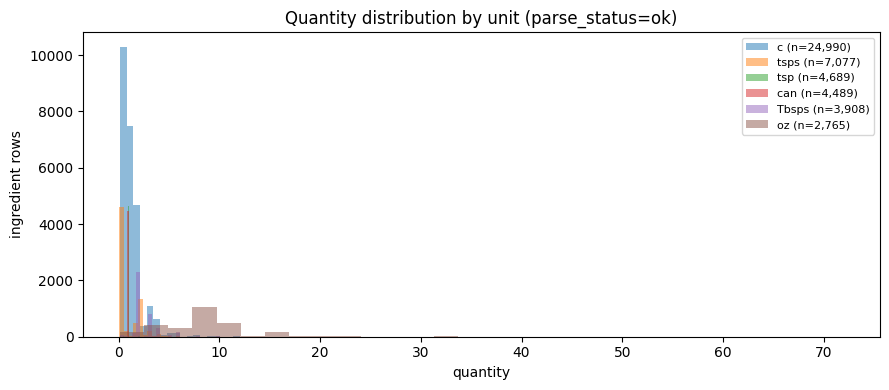

In [10]:
import matplotlib.pyplot as plt

ok = recipe_ingredients.loc[
    recipe_ingredients["parse_status"].eq("ok") & recipe_ingredients["unit"].notna()
]
top_units = ok["unit"].value_counts().head(6).index
plot_df = ok.loc[ok["unit"].isin(top_units)]

fig, ax = plt.subplots(figsize=(9, 4))
for unit in top_units:
    subset = plot_df.loc[plot_df["unit"] == unit, "quantity"].dropna()
    if len(subset):
        ax.hist(subset, bins=30, alpha=0.5, label=f"{unit} (n={len(subset):,})")
ax.set_xlabel("quantity")
ax.set_ylabel("ingredient rows")
ax.set_title("Quantity distribution by unit (parse_status=ok)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()